# libraries

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# XGBoost
from xgboost import XGBClassifier


ModuleNotFoundError: No module named 'xgboost'

# Data clening and loading , data understanding

In [ ]:
data=pd.read_csv("OnlineRetail.csv",encoding="ISO-8859-1")
print("retail data: ")
print(data.head())
print("description of Data")
print(data.describe())
print("Data Info")
print(data.info())
data.isnull().sum()


retail data: 
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
description of Data
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
data.duplicated().sum()

np.int64(5268)

# Data Preprossing

### Handling Missing Values 

In [ ]:
data_clean=data.dropna(subset=['CustomerID']).copy()
print(f"Shape after removing missing Customer IDs: {data_clean.shape}")
print(f"Remaining missing descriptions: {data_clean['Description'].isnull().sum()}")

Shape after removing missing Customer IDs: (406829, 8)
Remaining missing descriptions: 0


### Removing Duplicate Records

In [ ]:
data_clean.info()
data_clean.isnull().sum()
data_clean.drop_duplicates(inplace=True)

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  str    
 1   StockCode    406829 non-null  str    
 2   Description  406829 non-null  str    
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  str    
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 54.2 MB


### Handling Incorrect Data Entries (Data Anomalies)

In [ ]:
data_clean = data_clean[(data_clean['Quantity'] > 0) & (data_clean['UnitPrice'] > 0)]

print(f"Shape after filtering out cancellations and zero-priced items: {data_clean.shape}")
print(f"Minimum Quantity check: {data_clean['Quantity'].min()}")
print(f"Minimum UnitPrice check: {data_clean['UnitPrice'].min()}")

Shape after filtering out cancellations and zero-priced items: (392692, 8)
Minimum Quantity check: 1
Minimum UnitPrice check: 0.001


### Outlier Detection and Treatment (Winsorization)

In [ ]:
def treat_outliers_iqr(dataframe, column_name):
    Q1 = dataframe[column_name].quantile(0.25)
    Q3 = dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values outside boundarie
    dataframe[column_name] = np.clip(dataframe[column_name], lower_bound, upper_bound)
    return dataframe

data_clean = treat_outliers_iqr(data_clean, 'Quantity')
data_clean = treat_outliers_iqr(data_clean, 'UnitPrice')

print("Outliers capped successfully!")
print(f"New Maximum Quantity: {data_clean['Quantity'].max()}")
print(f"New Maximum UnitPrice: {data_clean['UnitPrice'].max()}")

Outliers capped successfully!
New Maximum Quantity: 27
New Maximum UnitPrice: 7.5


### Categorical Variable Encoding

In [ ]:
data_encoded = pd.get_dummies(data_clean, columns=['Country'], drop_first=True, prefix='Country')
print(f"Shape after One-Hot Encoding: {data_encoded.shape}")
print(data_encoded.filter(like='Country_').head())

   Country_Austria  Country_Bahrain  Country_Belgium  Country_Brazil  \
0            False            False            False           False   
1            False            False            False           False   
2            False            False            False           False   
3            False            False            False           False   
4            False            False            False           False   

   Country_Canada  Country_Channel Islands  Country_Cyprus  \
0           False                    False           False   
1           False                    False           False   
2           False                    False           False   
3           False                    False           False   
4           False                    False           False   

   Country_Czech Republic  Country_Denmark  Country_EIRE  ...  Country_RSA  \
0                   False            False         False  ...        False   
1                   False            F

### Feature Scaling

In [ ]:

scaler = StandardScaler()

scaled_features = scaler.fit_transform(data_clean[['Quantity', 'UnitPrice']])

data_clean['Quantity_Scaled'] = scaled_features[:, 0]
data_clean['UnitPrice_Scaled'] = scaled_features[:, 1]

print("--- Final Cleaned & Scaled Data Review ---")
print(data_clean[['Quantity', 'UnitPrice', 'Quantity_Scaled', 'UnitPrice_Scaled']].describe())

--- Final Cleaned & Scaled Data Review ---
            Quantity      UnitPrice  Quantity_Scaled  UnitPrice_Scaled
count  392692.000000  392692.000000     3.926920e+05      3.926920e+05
mean        8.393176       2.602209     1.158026e-17      1.435952e-16
std         8.109098       2.106173     1.000001e+00      1.000001e+00
min         1.000000       0.001000    -9.117149e-01     -1.235042e+00
25%         2.000000       1.250000    -7.883965e-01     -6.420228e-01
50%         6.000000       1.950000    -2.951227e-01     -3.096659e-01
75%        12.000000       3.750000     4.447879e-01      5.449660e-01
max        27.000000       7.500000     2.294565e+00      2.325449e+00


# Exploratory Data Analysis (EDA)

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
data_clean['TotalAmount'] = data_clean['Quantity'] * data_clean['UnitPrice']

print("Visualization environment configured successfully!")

Visualization environment configured successfully!


### Histograms (Frequency Distribution)

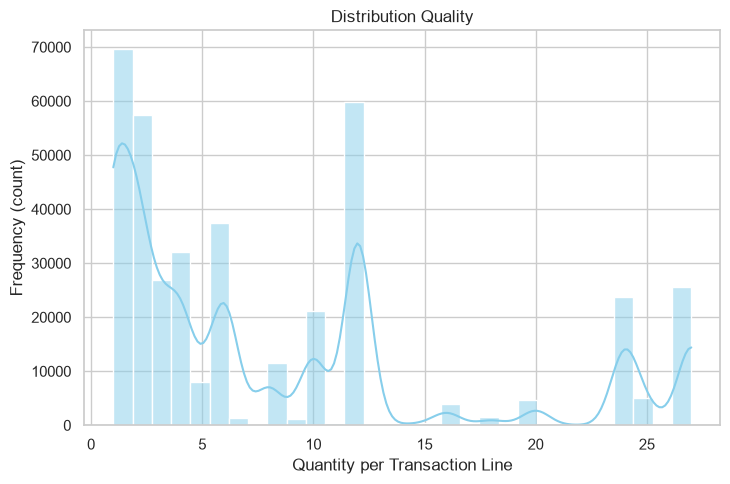

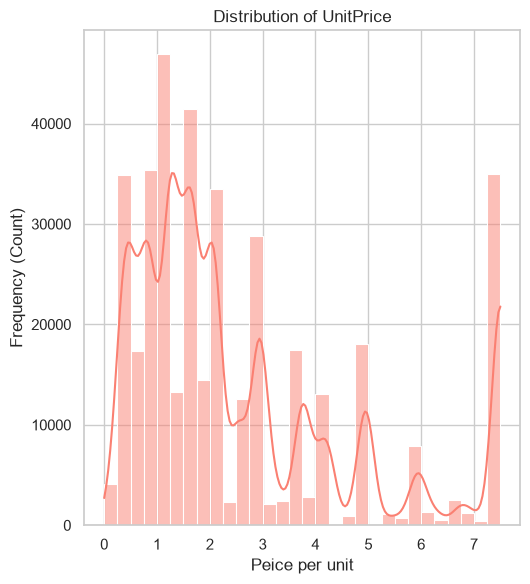

In [ ]:
plt.figure(figsize=(14,5))
# Distribution of Order Quantities
plt.subplot(1,2,1)
sns.histplot(data_clean['Quantity'],bins=30,kde=True,color='skyblue')
plt.title("Distribution Quality")
plt.xlabel("Quantity per Transaction Line")
plt.ylabel('Frequency (count)')
plt.tight_layout()
plt.show()
# Distribution of Unit Price
plt.subplot(1,2,1)
sns.histplot(data_clean['UnitPrice'],bins=30,kde=True,color='salmon')
plt.title("Distribution of UnitPrice")
plt.xlabel('Peice per unit')
plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

### Box Plots (Outlier Identification)

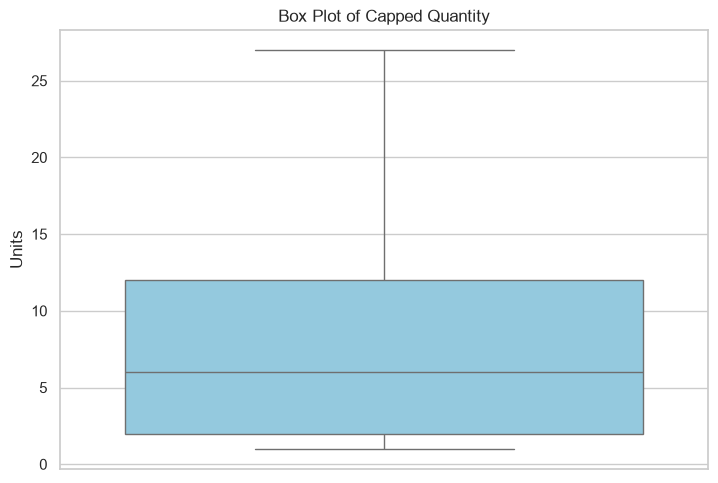

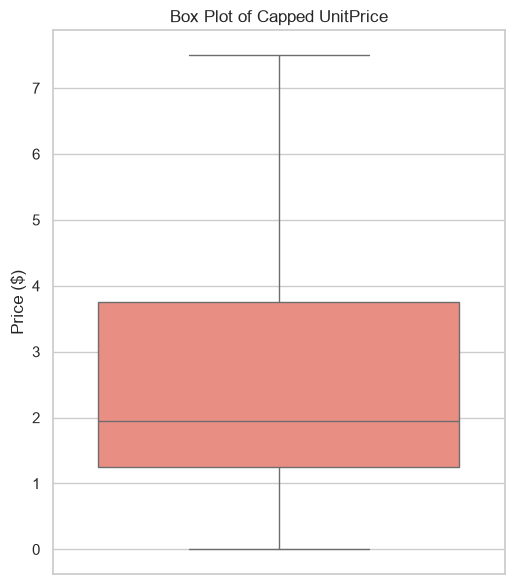

In [ ]:
plt.figure(figsize=(14, 5))

# Subplot 1: Quantity Spread
plt.subplot(1, 2, 1)
sns.boxplot(y=data_clean['Quantity'], color='skyblue')
plt.title('Box Plot of Capped Quantity')
plt.ylabel('Units')
plt.tight_layout()
plt.show()

# Subplot 2: UnitPrice Spread
plt.subplot(1, 2, 2)
sns.boxplot(y=data_clean['UnitPrice'], color='salmon')
plt.title('Box Plot of Capped UnitPrice')
plt.ylabel('Price ($)')

plt.tight_layout()
plt.show()

### Count Plot (Categorical Frequency Distribution)

C:\Users\dasri\AppData\Local\Temp\ipykernel_13080\2164585342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


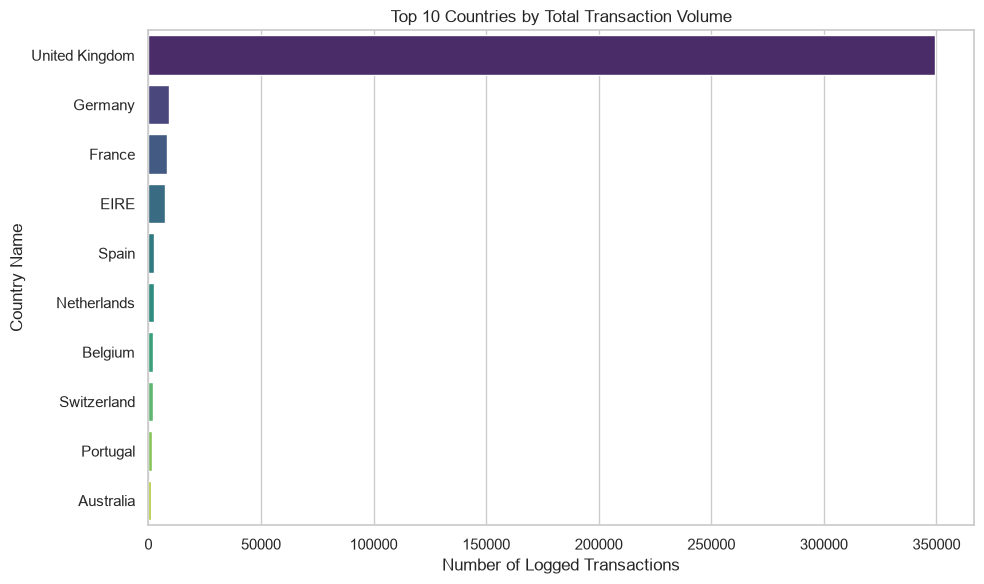

In [ ]:
plt.figure(figsize=(10, 6))

top_countries = data_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Transaction Volume')
plt.xlabel('Number of Logged Transactions')
plt.ylabel('Country Name')

plt.tight_layout()
plt.show()

### Scatter Plot (Bivariate Relationship)

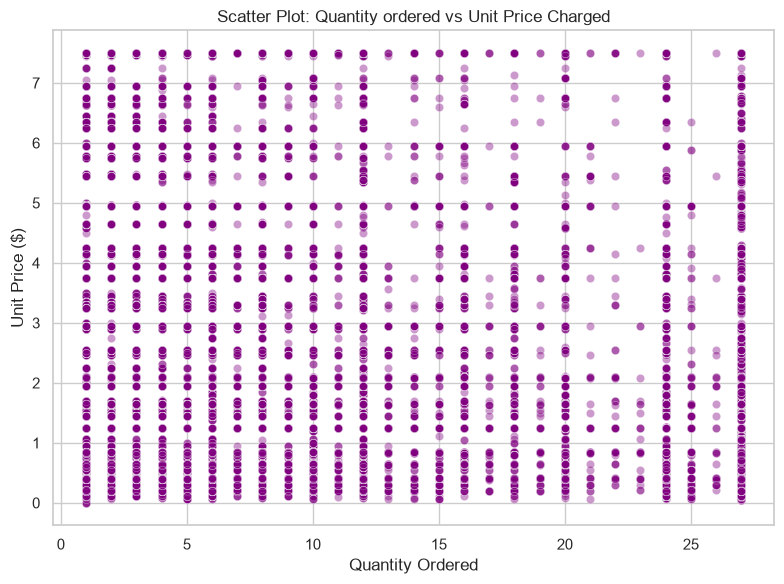

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=data_clean, x='Quantity', y='UnitPrice', alpha=0.4, color='purple')
plt.title('Scatter Plot: Quantity ordered vs Unit Price Charged')
plt.xlabel('Quantity Ordered')
plt.ylabel('Unit Price ($)')

plt.tight_layout()
plt.show()

### Correlation Heatmap (Feature Linear Co-linearity)

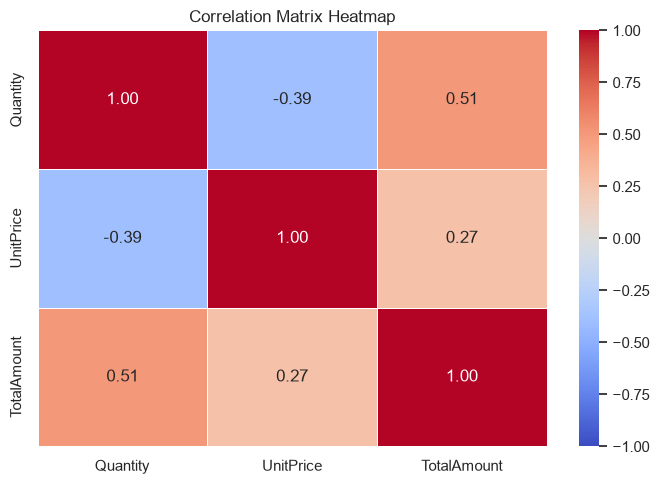

In [ ]:
plt.figure(figsize=(7, 5))
numeric_features = data_clean[['Quantity', 'UnitPrice', 'TotalAmount']]
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

### Distribution Plot (Continuous Probability Density)

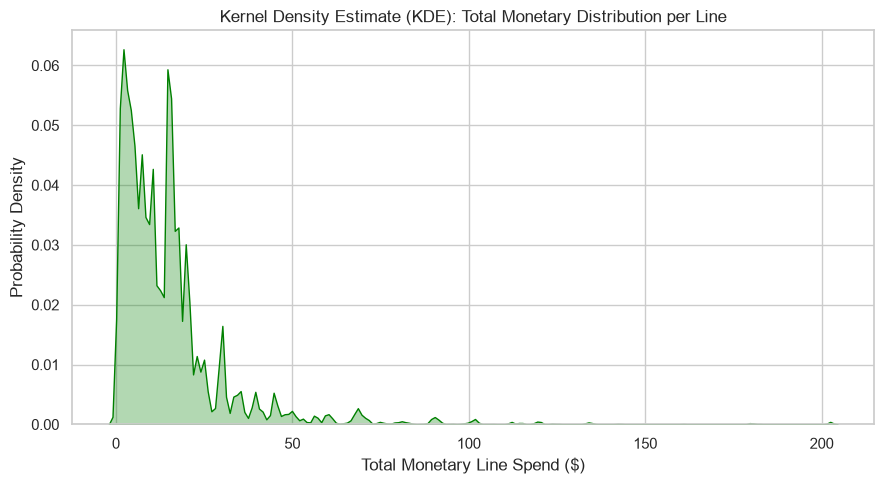

In [ ]:
plt.figure(figsize=(9, 5))
sns.kdeplot(data=data_clean, x='TotalAmount', fill=True, color='green', alpha=0.3, bw_adjust=0.5)
plt.title('Kernel Density Estimate (KDE): Total Monetary Distribution per Line')
plt.xlabel('Total Monetary Line Spend ($)')
plt.ylabel('Probability Density')

plt.tight_layout()
plt.show()

### Creating New Features & Removing Unnecessary Columns 

Remove Unnecessary Columns
'Description' contains unstructured text that requires NLP pipelines and doesn't add quantitative value here.
 'InvoiceNo' and 'StockCode' are high-cardinality unique system keys that cause extreme variance if encoded.

In [ ]:
# Ensure InvoiceDate is explicitly in datetime format
data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'], errors='coerce')

# 1. Create Line-Item Level Features
data_clean['TotalAmount'] = data_clean['Quantity'] * data_clean['UnitPrice']

# Extract temporal patterns from the timestamp
data_clean['InvoiceHour'] = data_clean['InvoiceDate'].dt.hour
data_clean['InvoiceDayOfWeek'] = data_clean['InvoiceDate'].dt.dayofweek
data_clean['InvoiceMonth'] = data_clean['InvoiceDate'].dt.month
columns_to_drop = ['Description', 'InvoiceNo', 'StockCode']
df_feature_engineered = data_clean.drop(columns=columns_to_drop)

print("--- Dataframe After Basic Feature Transformations ---")
print(df_feature_engineered.head())

--- Dataframe After Basic Feature Transformations ---
   Quantity         InvoiceDate  UnitPrice  CustomerID         Country  \
0         6 2010-01-12 08:26:00       2.55     17850.0  United Kingdom   
1         6 2010-01-12 08:26:00       3.39     17850.0  United Kingdom   
2         8 2010-01-12 08:26:00       2.75     17850.0  United Kingdom   
3         6 2010-01-12 08:26:00       3.39     17850.0  United Kingdom   
4         6 2010-01-12 08:26:00       3.39     17850.0  United Kingdom   

   Quantity_Scaled  UnitPrice_Scaled  TotalAmount  InvoiceHour  \
0        -0.295123         -0.024789        15.30          8.0   
1        -0.295123          0.374040        20.34          8.0   
2        -0.048486          0.070170        22.00          8.0   
3        -0.295123          0.374040        20.34          8.0   
4        -0.295123          0.374040        20.34          8.0   

   InvoiceDayOfWeek  InvoiceMonth  
0               1.0           1.0  
1               1.0           1.

### Feature Engineering

In [ ]:
data_clean['InvoiceDate'] = pd.to_datetime(data_clean['InvoiceDate'], dayfirst=True, errors='coerce')
data_clean = data_clean.dropna(subset=['InvoiceDate'])

snapshot_date = data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_data = data_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Quantity': ['sum', 'mean'],                             # Volume
    'UnitPrice': 'mean',                                     # Ticket Sizes
    'TotalAmount': 'sum'                                     # Gross Revenue
}).reset_index()

customer_data.columns = ['CustomerID', 'Recency_Days', 'Total_Quantity', 'Avg_Quantity', 'Avg_UnitPrice', 'Total_Spend']

# 5. Build binary classification targets
median_spend = customer_data['Total_Spend'].median()
customer_data['HighValueCustomer'] = (customer_data['Total_Spend'] > median_spend).astype(int)

print("--- Missing Values Verification ---")
print(customer_data.isnull().sum())
print(f"\nTotal clean unique customers ready for training: {customer_data.shape[0]}")

--- Missing Values Verification ---
CustomerID           0
Recency_Days         0
Total_Quantity       0
Avg_Quantity         0
Avg_UnitPrice        0
Total_Spend          0
HighValueCustomer    0
dtype: int64

Total clean unique customers ready for training: 2997


# Model Training

### traning data spliting

In [ ]:
X = customer_data[['Recency_Days', 'Total_Quantity', 'Avg_Quantity', 'Avg_UnitPrice']]
y = customer_data['HighValueCustomer']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

def evaluate_model(model_name, model_object, is_scaled=True):
    X_tr = X_train_scaled if is_scaled else X_train
    X_ts = X_test_scaled if is_scaled else X_test
    
    model_object.fit(X_tr, y_train)
    
    predictions = model_object.predict(X_ts)
    probabilities = model_object.predict_proba(X_ts)[:, 1]
    
    # Calculate scores
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)
    
    print(f"=== {model_name} Evaluation ===")
    print(f"Accuracy:  {acc:.4f} (Overall correctness)")
    print(f"Precision: {prec:.4f} (When it predicts a VIP, how often is it right?)")
    print(f"Recall:    {rec:.4f} (What percentage of actual VIPs did it find?)")
    print(f"F1-Score:  {f1:.4f} (Balanced metric combining precision & recall)")
    print(f"ROC-AUC:   {auc:.4f} (Ability to tell high vs low value customers apart)")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("-" * 50 + "\n")
    
    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": auc}

all_results = []

### Logistic Regression


In [ ]:
lr_model=LogisticRegression(random_state=42)
lr_result=evaluate_model("Logistic Regression",lr_model,is_scaled=True)
all_results.append(lr_result)

=== Logistic Regression Evaluation ===
Accuracy:  0.8317 (Overall correctness)
Precision: 0.7506 (When it predicts a VIP, how often is it right?)
Recall:    0.9933 (What percentage of actual VIPs did it find?)
F1-Score:  0.8551 (Balanced metric combining precision & recall)
ROC-AUC:   0.9755 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[201  99]
 [  2 298]]
--------------------------------------------------



### K-Nearest Neighbors (KNN)


In [ ]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_result=evaluate_model("K- nearest Neighbor ",lr_model,is_scaled=True)
all_results.append(knn_result)

=== K- nearest Neighbor  Evaluation ===
Accuracy:  0.8317 (Overall correctness)
Precision: 0.7506 (When it predicts a VIP, how often is it right?)
Recall:    0.9933 (What percentage of actual VIPs did it find?)
F1-Score:  0.8551 (Balanced metric combining precision & recall)
ROC-AUC:   0.9755 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[201  99]
 [  2 298]]
--------------------------------------------------



### Naive Bayes


In [ ]:
nb_model=GaussianNB()
nb_result=evaluate_model("Naive Bayes",nb_model,is_scaled=True)
all_results.append(nb_result)

=== Naive Bayes Evaluation ===
Accuracy:  0.8817 (Overall correctness)
Precision: 0.8962 (When it predicts a VIP, how often is it right?)
Recall:    0.8633 (What percentage of actual VIPs did it find?)
F1-Score:  0.8795 (Balanced metric combining precision & recall)
ROC-AUC:   0.9388 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[270  30]
 [ 41 259]]
--------------------------------------------------



### Support Vector Machine (SVM)

In [ ]:
svm_model=SVC(kernel='rbf',probability=True,random_state=42)
svm_result=evaluate_model(" Support Vector Machine",svm_model,is_scaled=True)
all_results.append(svm_result)

c:\Users\dasri\ML projects\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


===  Support Vector Machine Evaluation ===
Accuracy:  0.8517 (Overall correctness)
Precision: 0.7844 (When it predicts a VIP, how often is it right?)
Recall:    0.9700 (What percentage of actual VIPs did it find?)
F1-Score:  0.8674 (Balanced metric combining precision & recall)
ROC-AUC:   0.9712 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[220  80]
 [  9 291]]
--------------------------------------------------



### Decision Tree

In [ ]:
dt_model=DecisionTreeClassifier(max_depth=5,random_state=42)
dt_result=evaluate_model("Decision tree",dt_model,is_scaled=True)
all_results.append(dt_result)

=== Decision tree Evaluation ===
Accuracy:  0.7200 (Overall correctness)
Precision: 0.6410 (When it predicts a VIP, how often is it right?)
Recall:    1.0000 (What percentage of actual VIPs did it find?)
F1-Score:  0.7812 (Balanced metric combining precision & recall)
ROC-AUC:   0.8470 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[132 168]
 [  0 300]]
--------------------------------------------------



### Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_results = evaluate_model("Random Forest", rf_model, is_scaled=True)
all_results.append(rf_results)

=== Random Forest Evaluation ===
Accuracy:  0.6917 (Overall correctness)
Precision: 0.6190 (When it predicts a VIP, how often is it right?)
Recall:    0.9967 (What percentage of actual VIPs did it find?)
F1-Score:  0.7637 (Balanced metric combining precision & recall)
ROC-AUC:   0.9599 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[116 184]
 [  1 299]]
--------------------------------------------------



### XGBoost (Extreme Gradient Boosting)

In [ ]:
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42)
xgb_results = evaluate_model("XGBoost", xgb_model, is_scaled=True)
all_results.append(xgb_results)

=== XGBoost Evaluation ===
Accuracy:  0.6933 (Overall correctness)
Precision: 0.6203 (When it predicts a VIP, how often is it right?)
Recall:    0.9967 (What percentage of actual VIPs did it find?)
F1-Score:  0.7647 (Balanced metric combining precision & recall)
ROC-AUC:   0.9409 (Ability to tell high vs low value customers apart)

Confusion Matrix:
[[117 183]
 [  1 299]]
--------------------------------------------------



In [ ]:
summary_df = pd.DataFrame(all_results).sort_values(by="ROC-AUC", ascending=False)
print("=== FINAL MODEL COMPARISON SCOREBOARD ===")
print(summary_df.to_string(index=False))

=== FINAL MODEL COMPARISON SCOREBOARD ===
                  Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
    Logistic Regression  0.831667   0.750630 0.993333  0.855093 0.975489
   K- nearest Neighbor   0.831667   0.750630 0.993333  0.855093 0.975489
 Support Vector Machine  0.851667   0.784367 0.970000  0.867362 0.971244
          Random Forest  0.691667   0.619048 0.996667  0.763729 0.959889
                XGBoost  0.693333   0.620332 0.996667  0.764706 0.940900
            Naive Bayes  0.881667   0.896194 0.863333  0.879457 0.938800
          Decision tree  0.720000   0.641026 1.000000  0.781250 0.847006


In [ ]:
import joblib
joblib.dump(nb_model,'best_naive_bayse_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Naive Bayes Model and Scaler successfully saved!")


Naive Bayes Model and Scaler successfully saved!
